# Import Packages

In [340]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import missingno as msno
from pathlib import Path

In [341]:
# pathlib is a module in Python that provides an object-oriented interface 
# for working with file system paths.
current = Path.cwd()
parent = current.parent

## Read the CSV file into a DataFrame
df = pd.read_csv(parent / "data" / "swiggy.csv")
df.head(10)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
5,0x9bb4,HYDRES09DEL03,22,4.8,17.431668,78.408321,17.461668,78.438321,11-03-2022,21:20:00,21:30:00,conditions Cloudy,Jam,0,Buffet,motorcycle,1,No,Urban,(min) 26
6,0x95b4,RANCHIRES15DEL01,33,4.7,23.369746,85.339820,23.479746,85.449820,04-03-2022,19:15:00,19:30:00,conditions Fog,Jam,1,Meal,scooter,1,No,Metropolitian,(min) 40
7,0x9eb2,MYSRES15DEL02,35,4.6,12.352058,76.606650,12.482058,76.736650,14-03-2022,17:25:00,17:30:00,conditions Cloudy,Medium,2,Meal,motorcycle,1,No,Metropolitian,(min) 32
8,0x1102,HYDRES05DEL02,22,4.8,17.433809,78.386744,17.563809,78.516744,20-03-2022,20:55:00,21:05:00,conditions Stormy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 34
9,0xcdcd,DEHRES17DEL01,36,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55:00,22:10:00,conditions Fog,Jam,2,Snack,motorcycle,3,No,Metropolitian,(min) 46


In [342]:
# shape of the data
print(f"Data shape: {df.shape}")


Data shape: (45593, 20)


In [343]:
# datatypes of columns

(
    df.dtypes
    .rename("Data Type")
)

ID                              object
Delivery_person_ID              object
Delivery_person_Age             object
Delivery_person_Ratings         object
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weatherconditions               object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries             object
Festival                        object
City                            object
Time_taken(min)                 object
Name: Data Type, dtype: object

In [344]:
# information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

**Corrections**:

1. Age column should be numercial.
2. Rating should be float.
3. Date and time columns should be date and time.
4. Vehicle conditions seems to be categorical column which is integer encoded.
5. multiple deliveries should be integer column.
6. Target column should be a numbers.


In [345]:
# missing values in the data

df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [346]:
df.isnull().sum().sum()

np.int64(0)

** There are no missing values in the data **

In [347]:
df.sample(50)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
35260,0x5cd0,JAPRES18DEL02,33,5,26.913987,75.752891,26.963987,75.802891,21-03-2022,23:00:00,23:15:00,conditions Sunny,Low,0,Buffet,motorcycle,0,No,Metropolitian,(min) 22
40781,0x424b,MUMRES18DEL01,NaN,NaN,19.109300,72.825451,19.149300,72.865451,07-03-2022,NaN,13:35:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 28
34991,0xd1cc,ALHRES17DEL03,39,5,25.452350,81.841889,25.512350,81.901889,11-02-2022,21:00:00,21:05:00,conditions Sunny,Jam,1,Snack,motorcycle,1,No,Metropolitian,(min) 21
8602,0xdaad,BHPRES01DEL01,38,4.9,23.211529,77.419399,23.221529,77.429399,15-02-2022,11:35:00,11:50:00,conditions Sunny,High,1,Snack,motorcycle,1,No,Metropolitian,(min) 20
13380,0xc5ce,AGRRES18DEL03,24,4.8,27.161694,78.034714,27.301694,78.174714,18-02-2022,22:20:00,22:25:00,conditions Sandstorms,Low,2,Snack,motorcycle,1,No,Metropolitian,(min) 18
34132,0x95a2,SURRES06DEL01,33,5,21.185047,72.808590,21.295047,72.918590,27-03-2022,23:50:00,00:00:00,conditions Stormy,Low,0,Buffet,motorcycle,0,No,Metropolitian,(min) 24
2841,0xd2e1,KOLRES14DEL03,37,4.8,22.552996,88.352310,22.612996,88.412310,13-02-2022,18:30:00,18:35:00,conditions Sandstorms,Medium,2,Snack,motorcycle,1,No,Metropolitian,(min) 26
19685,0xc048,ALHRES09DEL02,32,4.6,0.000000,0.000000,0.050000,0.050000,17-02-2022,17:10:00,17:15:00,conditions Fog,Medium,1,Meal,scooter,1,No,Urban,(min) 16
31036,0x12a7,VADRES03DEL02,29,4.1,22.320000,73.170000,22.340000,73.190000,30-03-2022,11:45:00,11:55:00,conditions Sunny,High,0,Meal,motorcycle,3,No,Metropolitian,(min) 50
12849,0x87fd,BANGRES20DEL03,33,4.2,12.972161,77.596014,13.032161,77.656014,30-03-2022,22:20:00,22:30:00,conditions Stormy,Low,0,Buffet,motorcycle,1,No,Metropolitian,(min) 27


# Missing values

Missing values are string type in the data with an extra space.

In [348]:
df.at[44642, "Delivery_person_Age"] 

'NaN '

In [349]:
# strings NaNs in the data
(df == "NaN ").sum().sum()

np.int64(8515)

In [350]:
# column wise string NaNs
(df == "NaN ").sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [351]:
# replace string NaNs with actual NaN
df.replace("NaN ", np.nan)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [352]:
# verfiy the missing values again
df.replace("NaN ", np.nan).isnull().sum().sum()

np.int64(8515)

In [353]:
(
    df.loc[:,"Weatherconditions"]
    .str.replace("conditions", "")
    .replace("NaN", np.nan)
    .isna().sum()
)

np.int64(0)

In [354]:
# df with all  the missing values replaced with NaN

missing_df  = (
    df.replace("NaN ", np.nan)
        .assign(
        Weatherconditions = lambda df_ : (
            df_['Weatherconditions']
            .str.replace("conditions ","")
            .replace("NaN",np.nan) )     
    )

)

missing_df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


In [355]:
missing_df.isnull().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions               616
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64

In [356]:
# total missing values in the data

missing_df.isnull().sum().sum()

np.int64(9131)

# Missing Value Analysis

## Matrix

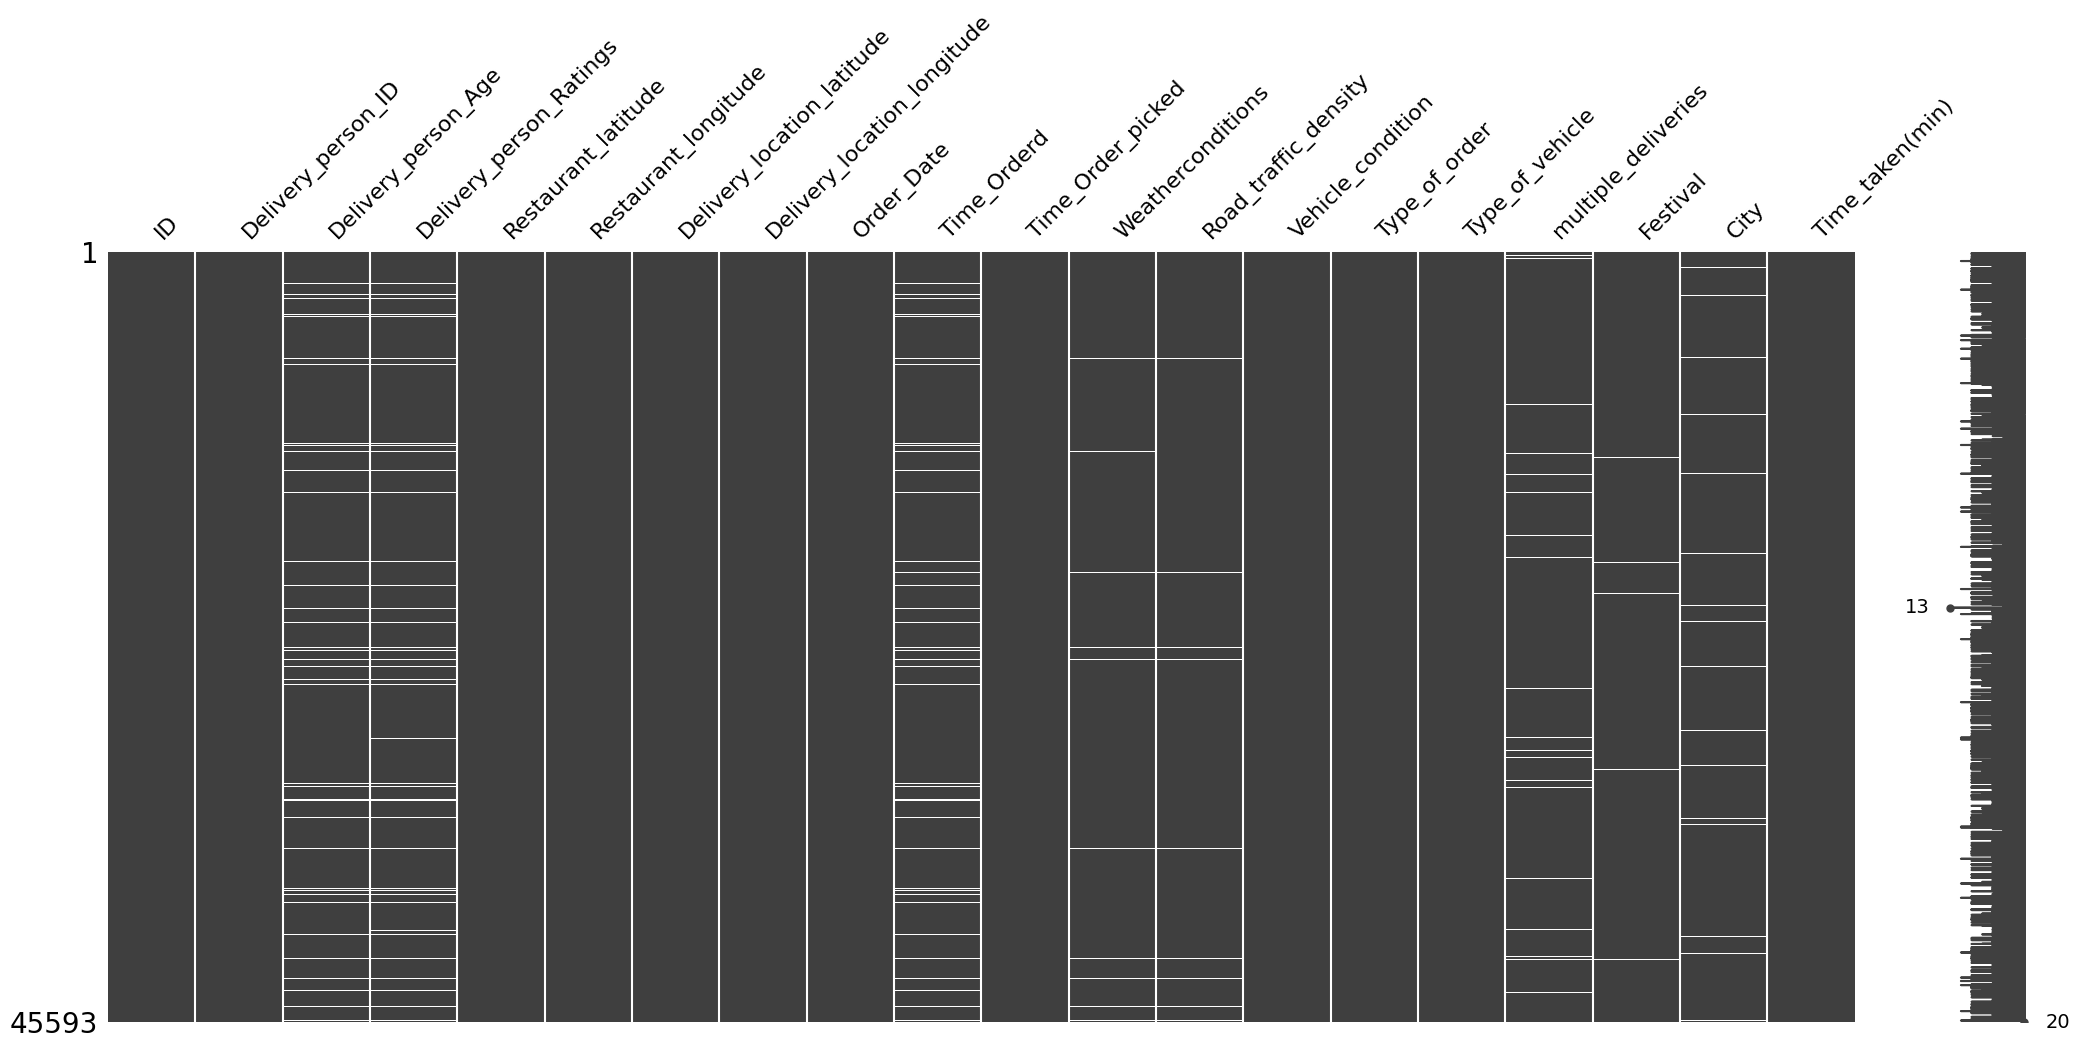

In [357]:
# missing values matrix

msno.matrix(missing_df)
plt.show()

### Count of missing values

<Axes: >

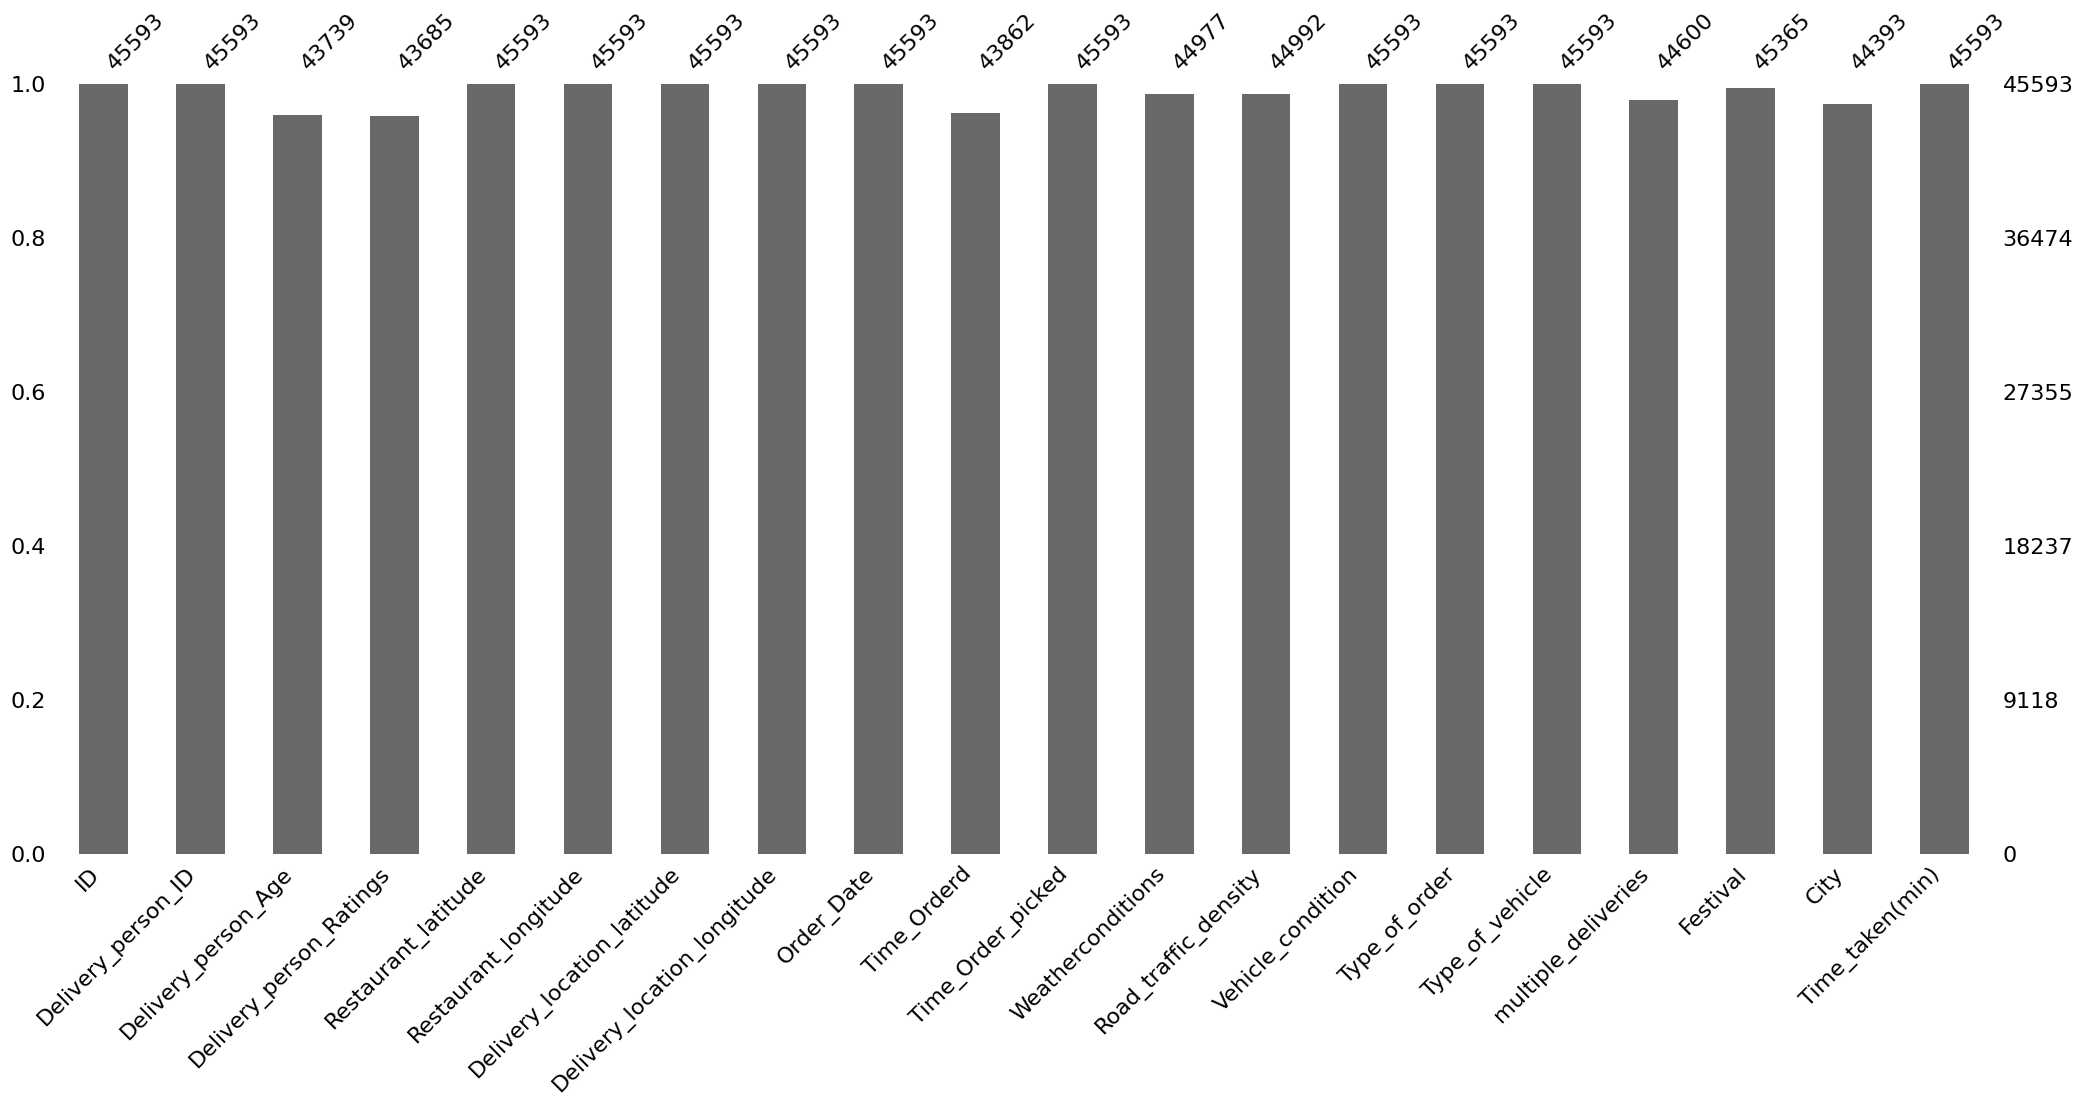

In [358]:
# bar plot  for columns having missing data

msno.bar(missing_df)

### Missing Corr

<Axes: >

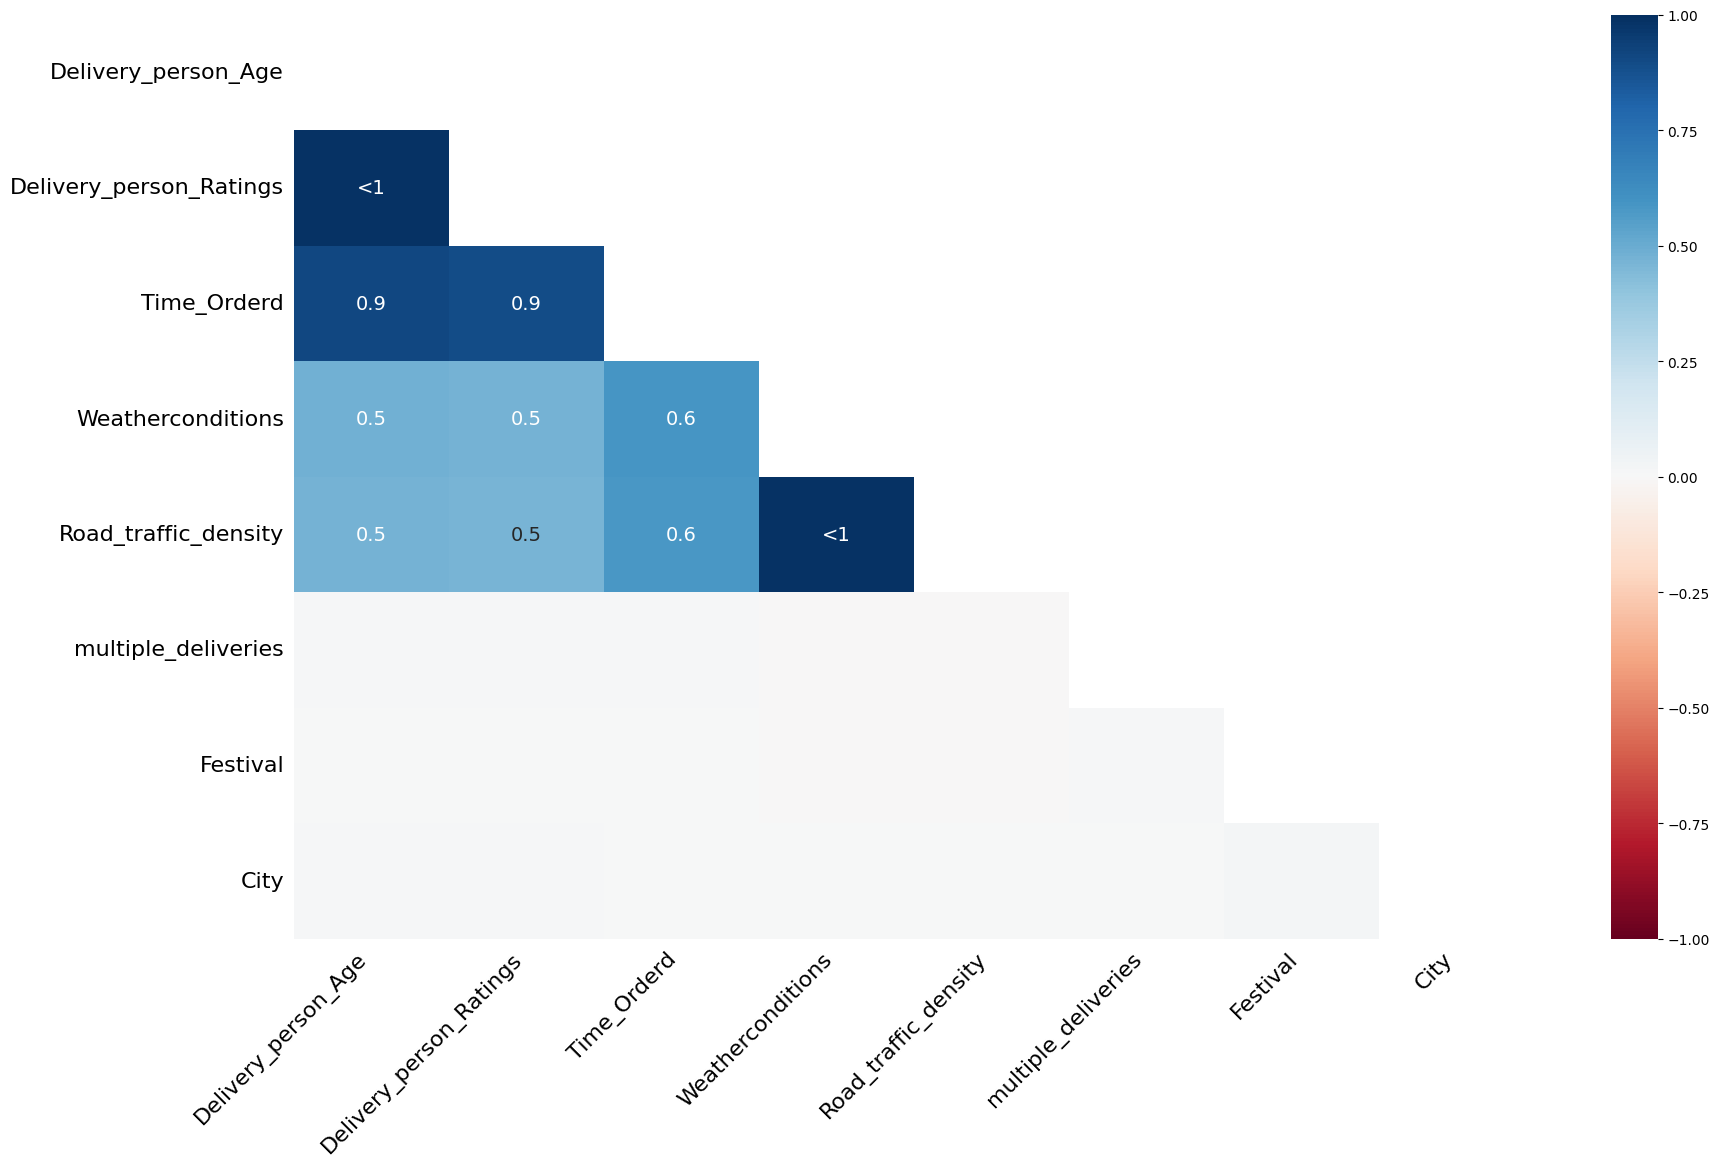

In [359]:
# missing data correlation matrix
msno.heatmap(missing_df)

**Observations**

1. The delivery person column and rating, time ordered the missingness are highly co-related 
2. The time ordered column is also related to the rider which shows that the data might be missing due to some network error where the system was unable to log rider details and time of order.
3. There is a very high correlation between weather patterns and the road traffic information. Be clear that this does not mean that the road traffic and weather columns are correlated. High corr in missingness means that if value in one column is missing, it is a high chance that it will be missing in others as well.
3. Road traffic density also shows correlation to the rider as it might be provided through the phone of rider (need to investigate).


In [360]:
missing_df[["Weatherconditions", "Road_traffic_density"]].isnull().sum()

Weatherconditions       616
Road_traffic_density    601
dtype: int64

In [361]:
(
    missing_df[["Weatherconditions","Road_traffic_density"]]
    .isna().all(axis=1)
    .sum()
)/missing_df[["Weatherconditions","Road_traffic_density"]].isna().sum()

Weatherconditions       0.975649
Road_traffic_density    1.000000
dtype: float64

<Axes: >

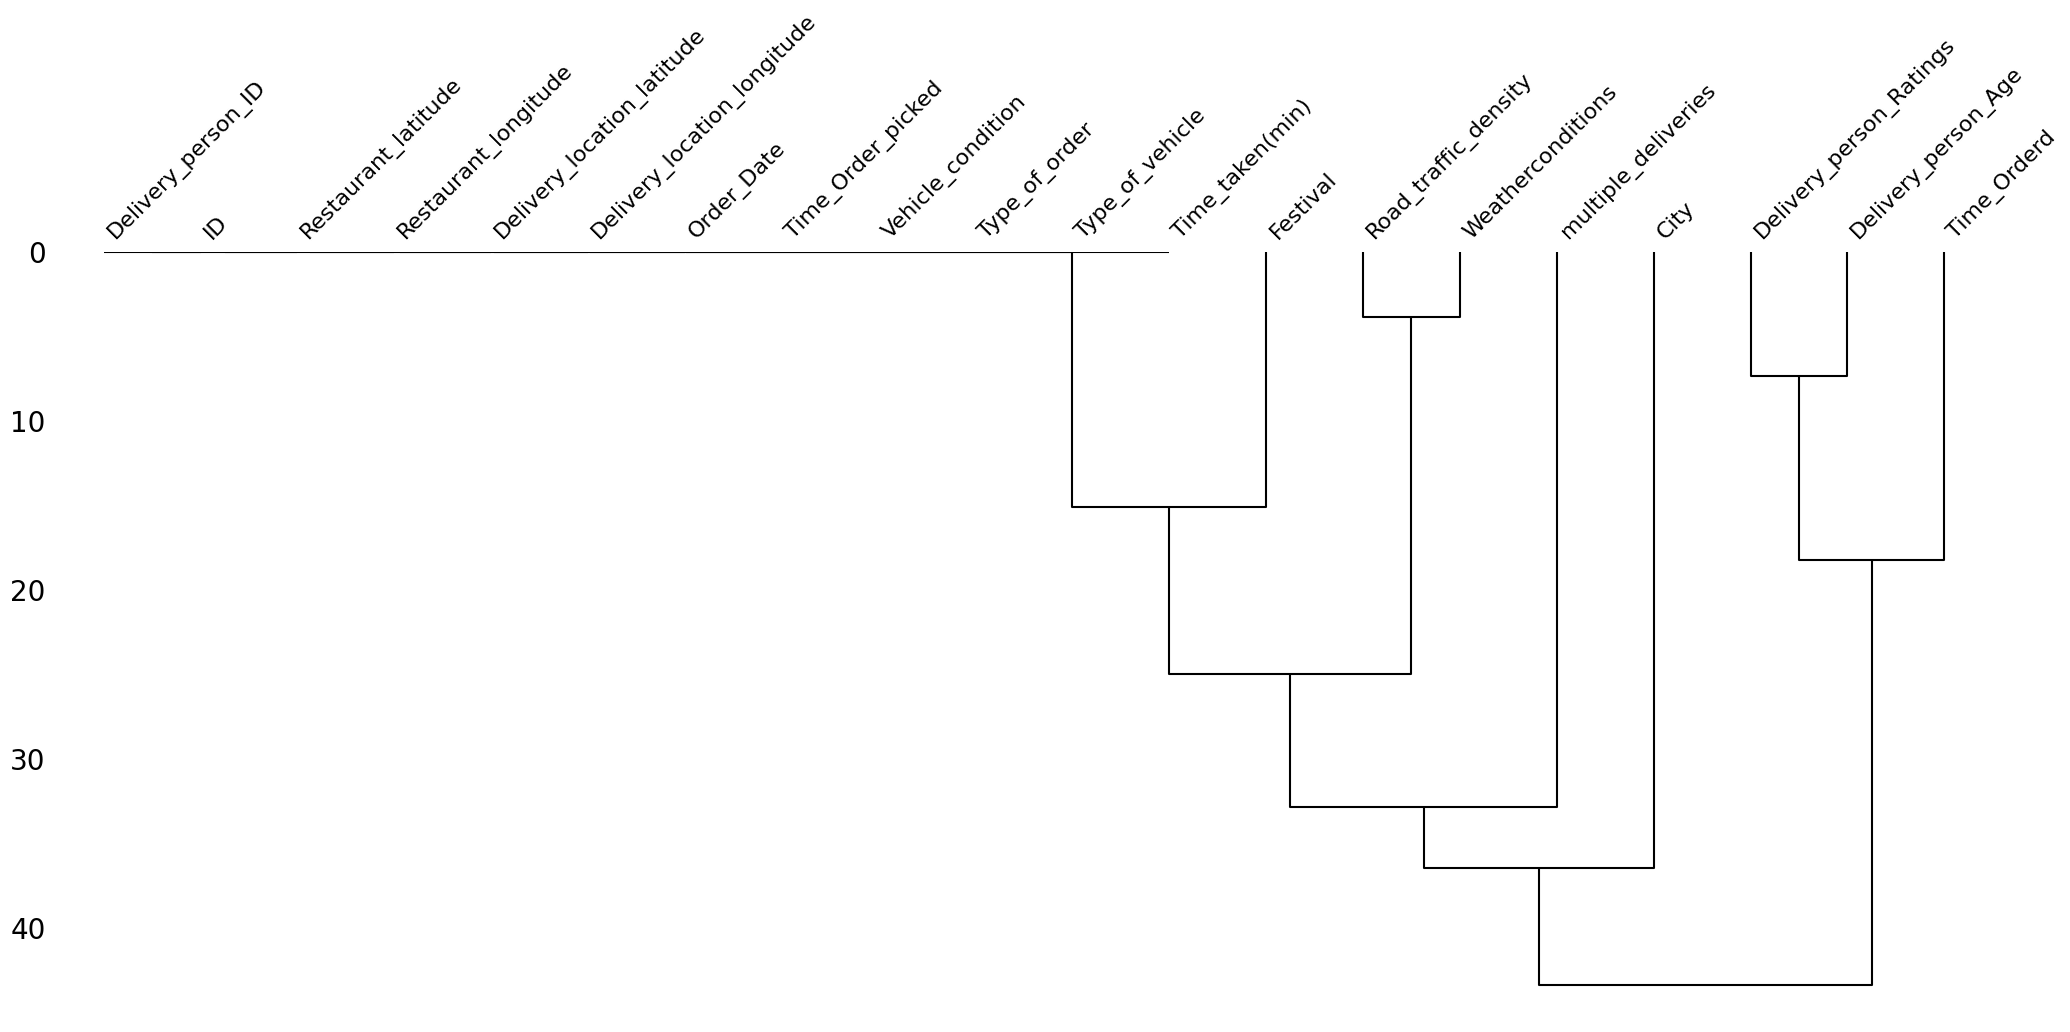

In [362]:
# dendrogram of missingness

msno.dendrogram(missing_df)

In [363]:
# percentage of missing values in the data having missing value

(missing_df .isna().any(axis=1).sum()/ missing_df.shape[0]) * 100

np.float64(9.266773408198627)

**About 9% of the rows in the data have missing values**

# Basic data cleaning

In [364]:
# name of the columns 
df.columns.tolist()

['ID',
 'Delivery_person_ID',
 'Delivery_person_Age',
 'Delivery_person_Ratings',
 'Restaurant_latitude',
 'Restaurant_longitude',
 'Delivery_location_latitude',
 'Delivery_location_longitude',
 'Order_Date',
 'Time_Orderd',
 'Time_Order_picked',
 'Weatherconditions',
 'Road_traffic_density',
 'Vehicle_condition',
 'Type_of_order',
 'Type_of_vehicle',
 'multiple_deliveries',
 'Festival',
 'City',
 'Time_taken(min)']

In [365]:
def change_column_names(data: pd.DataFrame):
    return (
        data.rename(str.lower,axis=1)
        .rename({
            "delivery_person_id" : "rider_id",
            "delivery_person_age": "age",
            "delivery_person_ratings": "ratings",
            "delivery_location_latitude": "delivery_latitude",
            "delivery_location_longitude": "delivery_longitude",
            "time_orderd": "order_time",
            "time_order_picked": "order_picked_time",
            "weatherconditions": "weather",
            "road_traffic_density": "traffic",
            "city": "city_type",
            "time_taken(min)": "time_taken"},axis=1)
    )

In [366]:
# change the column names

df = change_column_names(df)

In [367]:
df.head()

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [368]:
# check for duplicate rows
df[["id","rider_id"]].duplicated().sum()

np.int64(0)

**There are no duplicate rows in the data**

## Column Wise Cleaning

### ID

In [369]:
# unique items in id column

print(f"Unique items in id column: {df['id'].nunique()}")

Unique items in id column: 45593


**All the ID values are unique**

This column can be dropped from the data

### Rider Id

In [370]:
# unique rider ids in the column

df['rider_id'].nunique()

1320

In [371]:
df['rider_id'].value_counts()

rider_id
PUNERES01DEL01       67
JAPRES11DEL02        67
VADRES08DEL02        66
RANCHIRES02DEL01     66
HYDRES04DEL02        66
                     ..
BHPRES15DEL03         7
GOARES01DEL03         7
KOLRES09DEL03         6
KOCRES16DEL03         6
BHPRES010DEL03        5
Name: count, Length: 1320, dtype: int64

**The data contains 1320 unique riders**

In [372]:
# extract city name out of rider id

(
    df['rider_id']
    .str.split("RES")
    .str.get(0)
    .rename("City_name")
)

0          INDO
1          BANG
2          BANG
3         COIMB
4          CHEN
          ...  
45588       JAP
45589       AGR
45590      CHEN
45591     COIMB
45592    RANCHI
Name: City_name, Length: 45593, dtype: object

In [373]:
# datatype
df['age'].dtype

dtype('O')

In [374]:
df['age'].astype(float).describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: age, dtype: float64

**Minimum Rider age of 15 is concerning**

Investigate further what type of transport is he using?

<Axes: ylabel='age'>

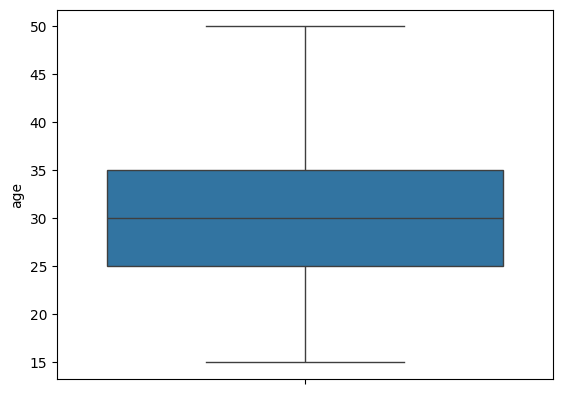

In [375]:
# boxplot for age column
sns.boxplot(df['age'].astype(float))

In [376]:
minors_data = df[df["age"].astype(float) <18]
minors_data

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
2387,0x564,JAPRES15DEL03,15,1,-26.891191,75.802083,26.981191,75.892083,12-03-2022,NaN,17:20:00,conditions NaN,NaN,3,Meal,motorcycle,0,No,Urban,(min) 15
2905,0xcd0,INDORES010DEL03,15,1,22.750040,75.902847,22.810040,75.962847,03-04-2022,NaN,20:30:00,conditions NaN,NaN,3,Snack,scooter,1,No,Metropolitian,(min) 29
2951,0x91a,SURRES17DEL03,15,1,21.149569,72.772697,21.209569,72.832697,21-03-2022,NaN,22:10:00,conditions NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 20
5902,0x474,CHENRES15DEL03,15,1,13.026286,80.275235,13.056286,80.305235,11-03-2022,NaN,20:50:00,conditions NaN,NaN,3,Drinks,bicycle,1,No,Metropolitian,(min) 25
9156,0x73f,BANGRES05DEL01,15,1,12.970324,77.645748,13.080324,77.755748,25-03-2022,NaN,23:25:00,conditions NaN,NaN,3,Buffet,motorcycle,2,No,Metropolitian,(min) 34
10900,0x1b49,MUMRES14DEL02,15,1,19.181300,72.836191,19.231300,72.886191,30-03-2022,NaN,20:55:00,conditions NaN,NaN,3,Buffet,motorcycle,1,No,Metropolitian,(min) 39
11125,0x40b,SURRES12DEL01,15,1,-21.183434,-72.814492,21.193434,72.824492,05-03-2022,NaN,11:30:00,conditions NaN,NaN,3,Meal,scooter,1,No,Urban,(min) 27
12093,0x523,INDORES03DEL02,15,1,22.751857,75.866699,22.801857,75.916699,24-03-2022,NaN,21:15:00,conditions NaN,NaN,3,Buffet,bicycle,0,No,Metropolitian,(min) 28
15124,0x18b0,RANCHIRES02DEL01,15,1,0.000000,0.000000,0.070000,0.070000,16-03-2022,NaN,23:55:00,conditions NaN,NaN,3,Meal,bicycle,1,No,Metropolitian,(min) 21
15927,0x550,CHENRES08DEL02,15,1,13.022394,80.242439,13.072394,80.292439,11-03-2022,NaN,18:10:00,conditions NaN,NaN,3,Snack,bicycle,0,No,Metropolitian,(min) 17


**Observations**:

1. The star ratings of all the riders is 1.
2. The vehicle condition of these riders is very bad.
3. No weather and traffic conditions available.
4. Age of all these riders is 15 which is below the permissable age to drive a vehicle.
5. Latitude and Longitude values in negative which is not possible. India is situated above the equator so all latitudes should be positive and east of meridian line so longitudes are positive as well.

In [377]:
minors_data.shape[0]*100/df.shape[0]
print(f"Percentage of minors in the data: {minors_data.shape[0]*100/df.shape[0]}%")

Percentage of minors in the data: 0.0833461276950409%


**Seems like removing this data for now makes more sense then fixing it because a lot of data is missing**

In [378]:
# rows of minors
minor_index = minors_data.index.tolist()
len(minor_index)

38

### Ratings

In [379]:
# datatype

df['ratings'].dtype

dtype('O')

In [380]:
# min,mean and max of ratings column
df['ratings'].astype(float).describe()

count    43685.000000
mean         4.633780
std          0.334716
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          6.000000
Name: ratings, dtype: float64

**6 Star rating is possibly a data error**

<Axes: ylabel='ratings'>

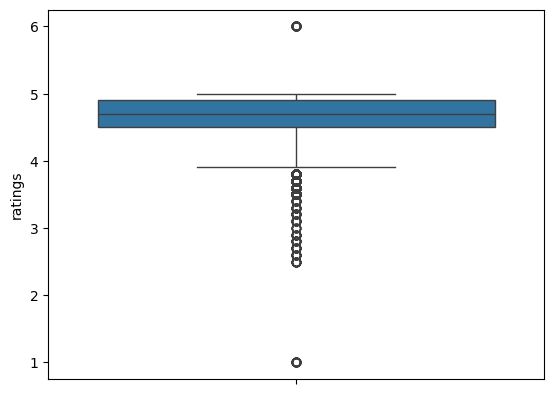

In [381]:
sns.boxplot(df['ratings'].astype(float))

In [382]:
# rows where the star rating is greater than 5

six_star_data = df[df['ratings'].astype(float) > 5]

len(six_star_data)

53

In [383]:
six_star_data.sample(10)

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
39699,0xa24,RANCHIRES14DEL03,50,6,0.000000,0.000000,0.030000,0.030000,21-03-2022,NaN,21:10:00,conditions NaN,NaN,3,Buffet,bicycle,1,No,Metropolitian,(min) 39
3586,0x46d,BANGRES05DEL01,50,6,-12.970324,-77.645748,13.010324,77.685748,13-03-2022,NaN,12:30:00,conditions NaN,NaN,3,Meal,electric_scooter,0,No,Urban,(min) 25
38020,0x466,CHENRES14DEL02,50,6,13.026279,80.174568,13.106279,80.254568,20-03-2022,NaN,23:10:00,conditions NaN,NaN,3,Meal,scooter,0,No,Metropolitian,(min) 14
34688,0xbf76,AGRRES20DEL03,50,6,-27.158822,-78.045359,27.248822,78.135359,14-02-2022,NaN,23:55:00,conditions NaN,NaN,3,Drinks,electric_scooter,1,No,Urban,(min) 16
28974,0x404,CHENRES04DEL01,50,6,-13.029780,-80.208812,13.099780,80.278812,18-03-2022,NaN,23:55:00,conditions NaN,NaN,3,Meal,electric_scooter,0,No,Metropolitian,(min) 20
17708,0x412,CHENRES010DEL01,50,6,-13.066762,-80.251865,13.076762,80.261865,17-03-2022,NaN,09:15:00,conditions NaN,NaN,3,Drinks,electric_scooter,1,No,Metropolitian,(min) 20
30943,0x4cc,MUMRES20DEL01,50,6,-19.103249,-72.846749,19.213249,72.956749,16-03-2022,NaN,22:00:00,conditions NaN,NaN,3,Meal,scooter,1,No,Urban,(min) 30
18977,0xc363,BHPRES08DEL03,50,6,23.232537,77.429845,23.322537,77.519845,18-02-2022,NaN,21:25:00,conditions NaN,NaN,3,Buffet,scooter,1,No,Metropolitian,(min) 17
14944,0x43c,HYDRES14DEL01,50,6,17.426228,78.407495,17.536228,78.517495,02-04-2022,NaN,22:50:00,conditions NaN,NaN,3,Meal,motorcycle,1,No,Urban,(min) 19
13652,0x434,RANCHIRES01DEL02,50,6,-23.416792,-85.316842,23.466792,85.366842,13-03-2022,NaN,20:40:00,conditions NaN,NaN,3,Buffet,motorcycle,0,No,Metropolitian,(min) 28


###  Additional Observations:

1. **Ratings > 5**:
   - All rows have a **rating of 6**.
   - Corresponding **age is always 50**.

2. **Restaurant Coordinates**:
   - Most **`restaurant_latitude` and `restaurant_longitude` values are negative**, which is unusual and likely incorrect for Indian locations.

3. **Missing Order Time**:
   - The column **`order_time` has NaN values**, suggesting missing time when the order was placed.

4. **Missing Traffic Information**:
   - The column **`traffic` is entirely NaN** in these rows — no traffic condition is recorded.

**Investigate further before action**

Data removal seems logical at this stage.

In [384]:
six_star_index = six_star_data.index.to_list()
print(len(six_star_data))

53


### Location Columns

In [385]:
location_columns = df.columns[4:8].to_list()
location_columns

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

In [386]:
location_subset = df.loc[:,location_columns]
location_subset.head()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982


**Valid values for lat and long**

 > India lies to the north of the equator between `6° 44′` and `35° 30′` north latitude and `68° 7′` and `97° 25′` east longitude.

In [387]:
location_subset.describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702
std,8.185109,22.883647,7.335122,21.118812
min,-30.905562,-88.366217,0.010000,0.010000
25%,12.933284,73.170000,12.988453,73.280000
50%,18.546947,75.898497,18.633934,76.002574
75%,22.728163,78.044095,22.785049,78.107044
max,30.914057,88.433452,31.054057,88.563452


In [388]:
# set the lower bound for latitude and longitude

lower_bound_lat = 6.44
lower_bound_long = 68.70

In [389]:
df[(df['restaurant_latitude'] < lower_bound_lat) |
   (df['restaurant_longitude'] < lower_bound_long) |
   (df['delivery_latitude'] < lower_bound_lat) |
    (df['delivery_longitude'] < lower_bound_long) 
   ].sample(20)

,id,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,order_time,order_picked_time,weather,traffic,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city_type,time_taken
8751,0xc466,AURGRES16DEL01,24,4.8,0.000000,0.000000,0.070000,0.070000,16-02-2022,23:25:00,23:40:00,conditions Sandstorms,Low,2,Buffet,scooter,0,No,NaN,(min) 17
32784,0xd41c,BHPRES02DEL01,28,4.7,0.000000,0.000000,0.040000,0.040000,13-02-2022,13:40:00,13:45:00,conditions Fog,High,0,Meal,motorcycle,1,No,Urban,(min) 24
24467,0x79fa,VADRES18DEL02,22,4.8,0.000000,0.000000,0.020000,0.020000,21-03-2022,10:40:00,10:45:00,conditions Sunny,Low,2,Meal,motorcycle,1,No,Metropolitian,(min) 17
36820,0xc0a8,BHPRES02DEL02,24,4.9,0.000000,0.000000,0.130000,0.130000,12-02-2022,22:45:00,22:55:00,conditions Windy,Low,0,Buffet,motorcycle,1,No,Urban,(min) 19
5530,0x63dc,VADRES04DEL02,29,4.9,0.000000,0.000000,0.130000,0.130000,18-03-2022,20:10:00,20:15:00,conditions Stormy,Jam,0,Drinks,motorcycle,1,No,Metropolitian,(min) 26
40539,0x814a,RANCHIRES02DEL02,37,4.5,0.000000,0.000000,0.020000,0.020000,17-03-2022,09:40:00,09:55:00,conditions Stormy,Low,2,Snack,electric_scooter,1,No,Metropolitian,(min) 23
39858,0x443,COIMBRES08DEL03,NaN,NaN,-11.001852,-76.976268,11.091852,77.066268,31-03-2022,NaN,21:05:00,conditions NaN,NaN,3,Snack,motorcycle,1,No,Metropolitian,(min) 54
16153,0x5bb9,VADRES16DEL03,37,4.7,0.000000,0.000000,0.090000,0.090000,23-03-2022,19:15:00,19:30:00,conditions Sunny,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 29
28728,0xe0d4,KNPRES08DEL01,32,4.8,0.000000,0.000000,0.010000,0.010000,15-02-2022,10:40:00,10:45:00,conditions Stormy,Low,2,Buffet,scooter,0,No,Metropolitian,(min) 23
15691,0x69f,VADRES09DEL02,NaN,NaN,0.000000,0.000000,0.130000,0.130000,25-03-2022,NaN,21:05:00,conditions Windy,Jam,0,Drinks,motorcycle,3,No,Metropolitian,(min) 51


In [390]:
# number of rows in data where lat long are erroneous

location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long)
].shape[0]

4071

**There are 4071 rows in the data where the lat long columns are messy**

In [391]:
# satitistical summary of the location data
location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long)
].describe()

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,4071.000000,4071.000000,4071.000000,4071.000000
mean,-2.149416,2.068601,2.212538,8.299885
std,6.537913,25.270676,6.538283,23.980011
min,-30.905562,-88.366217,0.010000,0.010000
25%,0.000000,0.000000,0.040000,0.040000
50%,0.000000,0.000000,0.070000,0.070000
75%,0.000000,0.000000,0.110000,0.110000
max,0.000000,88.433452,31.045562,88.523452


restaurant_latitude        Axes(0.125,0.53;0.352273x0.35)
restaurant_longitude    Axes(0.547727,0.53;0.352273x0.35)
delivery_latitude          Axes(0.125,0.11;0.352273x0.35)
delivery_longitude      Axes(0.547727,0.11;0.352273x0.35)
dtype: object

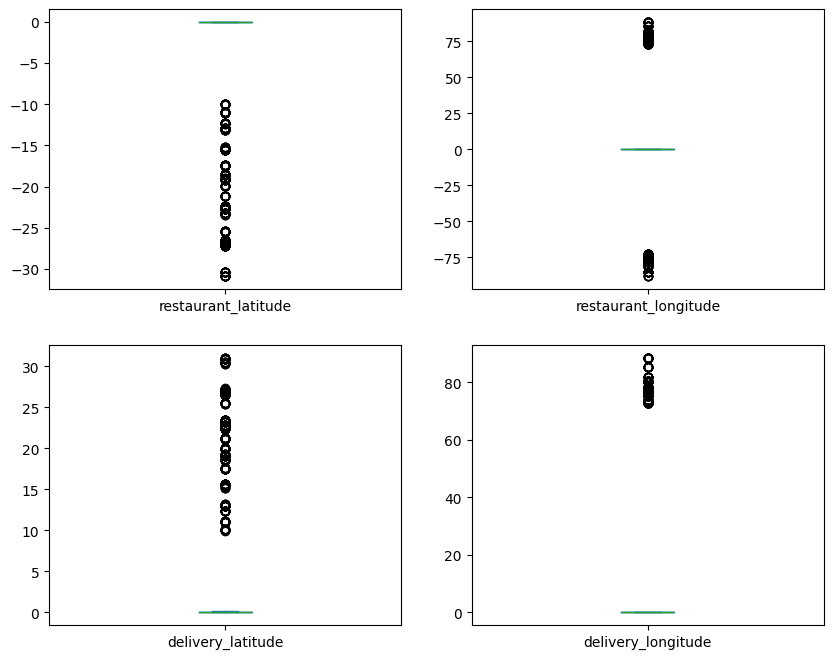

In [392]:
location_subset.loc[
    (location_subset['restaurant_latitude'] < lower_bound_lat) |
    (location_subset['restaurant_longitude'] < lower_bound_long) |
    (location_subset['delivery_latitude'] < lower_bound_lat) |
    (location_subset['delivery_longitude'] < lower_bound_long)
].plot(kind='box', subplots=True, layout=(2,2), figsize=(10,8))

### **Latitude & Longitude Observations**

1. **Invalid Restaurant Coordinates**:
   - Many values in **`restaurant_latitude`** and **`restaurant_longitude`** are **negative**.
   - Since **India lies entirely north of the equator (latitude)** and **east of the prime meridian (longitude)**, negative values are **invalid for Indian locations**.
   - ➤ These negative values likely indicate **data entry errors** (e.g., incorrect sign).

2. **Outlier Presence**:
   - The boxplots show **extreme outliers** in `restaurant_latitude` and `restaurant_longitude`, further confirming the presence of **erroneous or suspicious data**.

3. **Potential Correction**:
   - Rows with negative latitude or longitude for restaurants could potentially be fixed by converting them to positive (i.e., taking the **absolute value**), assuming this was a **sign error** during data entry.


[Text(1, 0, 'restaurant_latitude'),
 Text(2, 0, 'restaurant_longitude'),
 Text(3, 0, 'delivery_latitude'),
 Text(4, 0, 'delivery_longitude')]

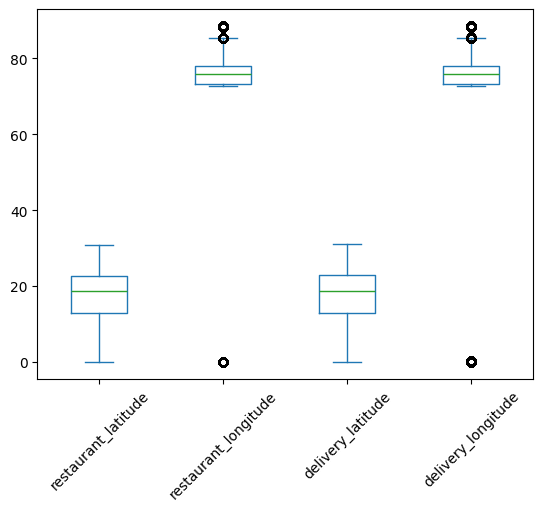

In [393]:
# taking the absolute values

(
    location_subset.abs()
    .plot(kind="box")
)

ax = plt.gca()

ax.set_xticklabels(ax.get_xticklabels(),rotation=45)

In [394]:
(
    location_subset.abs()
    .loc[lambda df_:
        (df_['restaurant_latitude'] < lower_bound_lat) |
        (df_['restaurant_longitude'] < lower_bound_long) |
        (df_['delivery_latitude'] < lower_bound_lat) |
        (df_['delivery_longitude'] < lower_bound_long)]
        .shape[0]
)


3640

In [395]:
lower_bound_lat

6.44

In [396]:
lower_bound_long

68.7

**`3640` rows in the data that have messy lat long values**

In [397]:
# lat long values less than 1

location_subset.abs().loc[lambda df_:
                        (df_['restaurant_latitude'] < 1) |
                        (df_['restaurant_longitude'] < 1) |
                        (df_['delivery_latitude'] < 1) |
                        (df_['delivery_longitude'] < 1)]

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
33,0.0,0.0,0.11,0.11
52,0.0,0.0,0.03,0.03
57,0.0,0.0,0.08,0.08
59,0.0,0.0,0.06,0.06
67,0.0,0.0,0.02,0.02
...,...,...,...,...
45569,0.0,0.0,0.07,0.07
45576,0.0,0.0,0.13,0.13
45577,0.0,0.0,0.09,0.09
45579,0.0,0.0,0.05,0.05


**All the messy lat long values are less than 1**

In [398]:
def clean_lat_long(data: pd.DataFrame, threshold =1):

    location_columns = location_subset.columns.tolist()

    return (    
        data.assign(**{
            col: (
                    np.where(data[col] < threshold,np.nan,data[col].values)
            )
            for col in location_columns

        })
    )

In [399]:
clean_lat_long(df).isna().sum()

id                         0
rider_id                   0
age                        0
ratings                    0
restaurant_latitude     4071
restaurant_longitude    3802
delivery_latitude       3640
delivery_longitude      3640
order_date                 0
order_time                 0
order_picked_time          0
weather                    0
traffic                    0
vehicle_condition          0
type_of_order              0
type_of_vehicle            0
multiple_deliveries        0
festival                   0
city_type                  0
time_taken                 0
dtype: int64

### Order Date

In [400]:
# check for missing values
df['order_date'].isna().sum()

np.int64(0)

In [401]:
# unique values in order date column
df['order_date'].unique()

array(['19-03-2022', '25-03-2022', '05-04-2022', '26-03-2022',
       '11-03-2022', '04-03-2022', '14-03-2022', '20-03-2022',
       '12-02-2022', '13-02-2022', '14-02-2022', '02-04-2022',
       '01-03-2022', '16-03-2022', '15-02-2022', '10-03-2022',
       '27-03-2022', '12-03-2022', '01-04-2022', '05-03-2022',
       '11-02-2022', '08-03-2022', '03-04-2022', '30-03-2022',
       '28-03-2022', '18-03-2022', '06-04-2022', '04-04-2022',
       '24-03-2022', '09-03-2022', '02-03-2022', '13-03-2022',
       '29-03-2022', '31-03-2022', '17-03-2022', '07-03-2022',
       '15-03-2022', '16-02-2022', '03-03-2022', '18-02-2022',
       '23-03-2022', '17-02-2022', '06-03-2022', '21-03-2022'],
      dtype=object)

In [402]:
# date range

order_date = pd.to_datetime(df['order_date'],dayfirst=True)

order_date.max() - order_date.min()

Timedelta('54 days 00:00:00')

In [403]:
# min and max date
order_date.agg(['min', 'max']).set_axis(['start', 'end'], axis=0)


start   2022-02-11
end     2022-04-06
Name: order_date, dtype: datetime64[ns]

In [404]:
# extract day,day name ,month and year

def extract_datetime_features(ser):
    date_col = pd.to_datetime(ser,dayfirst=True)

    return (
        pd.DataFrame({
            "day": date_col.dt.day,
            "month": date_col.dt.month,
            "year": date_col.dt.year,
            "day_of_week": date_col.dt.day_name(),
            "is_weekend": date_col.dt.day_name().isin(["Saturday","Sunday"]).astype(int)
        })

    )

In [405]:
extract_datetime_features(df['order_date'])

,day,month,year,day_of_week,is_weekend
0,19,3,2022,Saturday,1
1,25,3,2022,Friday,0
2,19,3,2022,Saturday,1
3,5,4,2022,Tuesday,0
4,26,3,2022,Saturday,1
...,...,...,...,...,...
45588,24,3,2022,Thursday,0
45589,16,2,2022,Wednesday,0
45590,11,3,2022,Friday,0
45591,7,3,2022,Monday,0


### Order time and Order picked time

In [406]:
# extract hour info from data
df[df['order_time'].isin(["NaN "])].shape[0]


1731

In [407]:
order_time_hr = pd.to_datetime(df.replace("NaN ",np.nan)['order_time'],format="mixed").dt.hour
order_time_hr.head(10)

0    11.0
1    19.0
2     8.0
3    18.0
4    13.0
5    21.0
6    19.0
7    17.0
8    20.0
9    21.0
Name: order_time, dtype: float64

In [408]:
# def time_of_day(ser):

#     time_col  = pd.to_datetime(ser,format="mixed").dt.hour

#     return (
#         np.select(
#             condlist=[
#                 (ser.between(6,12,inclusive='left')),
#                 (ser.between(12,17,inclusive='left')),
#                 (ser.between(17,20,inclusive='left')),
#                 (ser.between(20,24,inclusive='left'))],
#             choicelist=["morning","afternoon","evening","night"],
#             default="after_midnight"
#         )
#     )

def time_of_day(ser):

    return(
        pd.cut(ser,bins=[0,6,12,17,20,24],right=True,
               labels=["after_midnight","morning","afternoon","evening","night"])
    )

In [409]:
time_subset = df.loc[:,["order_time","order_picked_time"]]
time_subset

,order_time,order_picked_time
0,11:30:00,11:45:00
1,19:45:00,19:50:00
2,08:30:00,08:45:00
3,18:00:00,18:10:00
4,13:30:00,13:45:00
...,...,...
45588,11:35:00,11:45:00
45589,19:55:00,20:10:00
45590,23:50:00,00:05:00
45591,13:35:00,13:40:00


In [410]:
(
    time_subset
    .dtypes
)

order_time           object
order_picked_time    object
dtype: object

In [411]:
time_subset.columns.tolist()

['order_time', 'order_picked_time']

In [412]:
# calculate the pickup time

(
    time_subset
    .assign(**{     
        col : pd.to_datetime(time_subset[col].replace("NaN ",np.nan).dropna(),format="mixed")
        for col in time_subset.columns.tolist()}
        )
    .assign(
        pickup_time = lambda x: (x['order_picked_time'] - x['order_time']).dt.seconds / 60,
        order_time_hour = lambda x: x['order_time'].dt.hour,
        order_time_of_day = lambda x: x['order_time_hour'].pipe(time_of_day)
    )
    .drop(columns=["order_time","order_picked_time"])

)

,pickup_time,order_time_hour,order_time_of_day
0,15.0,11.0,morning
1,5.0,19.0,evening
2,15.0,8.0,morning
3,10.0,18.0,evening
4,15.0,13.0,afternoon
...,...,...,...
45588,10.0,11.0,morning
45589,15.0,19.0,evening
45590,15.0,23.0,night
45591,5.0,13.0,afternoon


### Weather

In [413]:
df['weather'].value_counts()

weather
conditions Fog           7654
conditions Stormy        7586
conditions Cloudy        7536
conditions Sandstorms    7495
conditions Windy         7422
conditions Sunny         7284
conditions NaN            616
Name: count, dtype: int64

In [414]:
# unique values
df['weather'].unique()

array(['conditions Sunny', 'conditions Stormy', 'conditions Sandstorms',
       'conditions Cloudy', 'conditions Fog', 'conditions Windy',
       'conditions NaN'], dtype=object)

In [415]:
# remove conditions from values

(
    df['weather']
    .str.replace("conditions ","")
    .unique()
)

array(['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', 'NaN'],
      dtype=object)

### Traffic

In [416]:
df['traffic'].value_counts()

traffic
Low        15477
Jam        14143
Medium     10947
High        4425
NaN          601
Name: count, dtype: int64

In [417]:
# unique values
df['traffic'].unique()

array(['High ', 'Jam ', 'Low ', 'Medium ', 'NaN '], dtype=object)

In [418]:
(
    df['traffic']
    .replace("NaN ",np.nan)
    .str.rstrip()
    .str.lower()
    .unique()
)

array(['high', 'jam', 'low', 'medium', nan], dtype=object)

### Vehicle Condition

In [419]:
np.sort(df['vehicle_condition'].unique())

array([0, 1, 2, 3])

### Type of order

In [420]:
df['type_of_order'].value_counts()

type_of_order
Snack      11533
Meal       11458
Drinks     11322
Buffet     11280
Name: count, dtype: int64

In [421]:
# unique values
df['type_of_order'].unique()

array(['Snack ', 'Drinks ', 'Buffet ', 'Meal '], dtype=object)

In [422]:
(
    df['type_of_order']
    .str.rstrip()
    .str.lower()
    .unique()
)

array(['snack', 'drinks', 'buffet', 'meal'], dtype=object)

### Type of vehicle

In [423]:
# value counts

df['type_of_vehicle'].value_counts()

type_of_vehicle
motorcycle           26435
scooter              15276
electric_scooter      3814
bicycle                 68
Name: count, dtype: int64

In [424]:
# unique values
df['type_of_vehicle'].unique()

array(['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle '],
      dtype=object)

In [425]:
(
    df['type_of_vehicle']
    .str.rstrip()
    .str.lower()
    .unique()
)

array(['motorcycle', 'scooter', 'electric_scooter', 'bicycle'],
      dtype=object)

### Multiple Deliveries

In [426]:
df['multiple_deliveries'].dtype

dtype('O')

In [427]:
# unique values in column

df['multiple_deliveries'].unique()

array(['0', '1', '3', 'NaN ', '2'], dtype=object)

In [428]:
# make the column as integer

(
    df['multiple_deliveries']
    .replace("NaN ",np.nan)
    .astype(float)
    .unique()
)

array([ 0.,  1.,  3., nan,  2.])

### Festival

In [429]:
df['festival'].unique()

array(['No ', 'Yes ', 'NaN '], dtype=object)

In [430]:
(
    df['festival']
    .replace("NaN ",np.nan)
    .str.rstrip()
    .str.lower()
    .unique()
)

array(['no', 'yes', nan], dtype=object)

### City type

In [431]:
df['city_type'].unique()

array(['Urban ', 'Metropolitian ', 'Semi-Urban ', 'NaN '], dtype=object)

In [432]:
(
    df['city_type']
    .replace("NaN ",np.nan)
    .str.rstrip()
    .str.lower()
    .unique()
)

array(['urban', 'metropolitian', 'semi-urban', nan], dtype=object)

### Time Taken

In [433]:
# datatype of time taken column
df['time_taken'].dtype

dtype('O')

In [434]:
df.loc[0,'time_taken']

'(min) 24'

In [435]:
(
    df['time_taken']
    .str.replace("(min) ","")
    .astype(int)
)

0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: time_taken, Length: 45593, dtype: int64

In [436]:
def data_cleaning(data: pd.DataFrame):

    return(
        data
        .drop(columns="id")
        .drop(index=minor_index)                                                # Minor riders in data dropped
        .drop(index=six_star_index)                                             # six star rated drivers dropped
        .replace("NaN ",np.nan)
        .assign(
            # extract city name out of rider id
            city_name = lambda x: x['rider_id'].str.split("RES").str.get(0),
            # convert age to float
            age = lambda x: x['age'].astype(float),
            # convert ratings to float
            ratings = lambda x: x['ratings'].astype(float),
            # abs values of lat long columns
            restaurant_latitude = lambda x: x['restaurant_latitude'].abs(),
            restaurant_longitude = lambda x: x['restaurant_longitude'].abs(),
            delivery_latitude = lambda x: x['delivery_latitude'].abs(),
            delivery_longitude = lambda x: x['delivery_longitude'].abs(),
            # order date to datetime and feature extraction
            order_date = lambda x: pd.to_datetime(x['order_date'],dayfirst=True),
            order_day = lambda x: x['order_date'].dt.day,
            order_month = lambda x: x['order_date'].dt.month,
            order_day_of_week = lambda x: x['order_date'].dt.day_name().str.lower(),
            is_weekend = lambda x: x['order_date'].dt.day_name().str.lower().isin(["saturday","sunday"]).astype(int),
            # order time to datetime and feature extraction
            order_time = lambda x: pd.to_datetime(x['order_time'],format="mixed"),
            order_picked_time = lambda x: pd.to_datetime(x['order_picked_time'],format="mixed"),
            pickup_time_minutes = lambda x: (x['order_picked_time'] - x['order_time']).dt.seconds / 60,
            # order time hour and time of day
            order_time_hour = lambda x: x['order_time'].dt.hour,
            order_time_of_day = lambda x: x['order_time_hour'].pipe(time_of_day),
            # weather conditions
            weather = lambda x: (
                                x['weather']
                                .str.replace("conditions ","")
                                .str.lower()
                                .replace("nan",np.nan)),
            traffic = lambda x: x["traffic"].str.rstrip().str.lower(),
            type_of_order = lambda x: x['type_of_order'].str.rstrip().str.lower(),
            type_of_vehicle = lambda x: x['type_of_vehicle'].str.rstrip().str.lower(),
            festival = lambda x: x['festival'].str.rstrip().str.lower(),
            city_type = lambda x: x['city_type'].str.rstrip().str.lower(),
            # multiple deliveries column
            multiple_deliveries = lambda x: x['multiple_deliveries'].astype(float),
            # target column modifications
            time_taken = lambda x: (x['time_taken']
                                    .str.replace("(min) ","")
                                    .astype(int)))
            .drop(columns=["order_time","order_picked_time"]) 

        )
          


In [437]:
data_cleaning(df)

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_type,time_taken,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,urban,24,INDO,19,3,saturday,1,15.0,11.0,morning
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,metropolitian,33,BANG,25,3,friday,0,5.0,19.0,evening
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,urban,26,BANG,19,3,saturday,1,15.0,8.0,morning
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,metropolitian,21,COIMB,5,4,tuesday,0,10.0,18.0,evening
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,metropolitian,30,CHEN,26,3,saturday,1,15.0,13.0,afternoon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,metropolitian,32,JAP,24,3,thursday,0,10.0,11.0,morning
45589,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,windy,jam,...,metropolitian,36,AGR,16,2,wednesday,0,15.0,19.0,evening
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,metropolitian,16,CHEN,11,3,friday,0,15.0,23.0,night
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,metropolitian,26,COIMB,7,3,monday,0,5.0,13.0,afternoon


In [438]:
cleaned_df = data_cleaning(df)
cleaned_df.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day'],
      dtype='object')

In [439]:
cleaned_df['is_weekend'].unique()

array([1, 0])

In [440]:
location_subset


,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
0,22.745049,75.892471,22.765049,75.912471
1,12.913041,77.683237,13.043041,77.813237
2,12.914264,77.678400,12.924264,77.688400
3,11.003669,76.976494,11.053669,77.026494
4,12.972793,80.249982,13.012793,80.289982
...,...,...,...,...
45588,26.902328,75.794257,26.912328,75.804257
45589,0.000000,0.000000,0.070000,0.070000
45590,13.022394,80.242439,13.052394,80.272439
45591,11.001753,76.986241,11.041753,77.026241


In [441]:
location_subset.columns.tolist()

['restaurant_latitude',
 'restaurant_longitude',
 'delivery_latitude',
 'delivery_longitude']

>The Haversine formula calculates the shortest distance between two points on a sphere (like Earth) given their latitude and longitude.

In [442]:
def calculate_haversine_distance(df):
    location_columns = location_subset.columns.tolist()
    lat1 = df['restaurant_latitude']
    lon1 = df['restaurant_longitude']
    lat2 = df['delivery_latitude']  
    lon2 = df['delivery_longitude']

    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = np.sin(
        dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2

    c = 2 * np.arcsin(np.sqrt(a))
    distance = 6371 * c

    return (
        df.assign(
            distance = distance)
    )

In [443]:
def create_distance_type(data: pd.DataFrame):
    return(
        data
        .assign(
                distance_type = pd.cut(data["distance"],bins=[0,5,10,15,25],
                                        right=False,labels=["short","medium","long","very_long"])
    ))

In [444]:
# add more data cleaning steps

cleaned_data = (
                df.pipe(data_cleaning)
                .pipe(clean_lat_long)
                .pipe(calculate_haversine_distance)
                .pipe(create_distance_type)
                )

cleaned_data

,rider_id,age,ratings,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude,order_date,weather,traffic,...,city_name,order_day,order_month,order_day_of_week,is_weekend,pickup_time_minutes,order_time_hour,order_time_of_day,distance,distance_type
0,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,sunny,high,...,INDO,19,3,saturday,1,15.0,11.0,morning,3.025149,short
1,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,stormy,jam,...,BANG,25,3,friday,0,5.0,19.0,evening,20.183530,very_long
2,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,sandstorms,low,...,BANG,19,3,saturday,1,15.0,8.0,morning,1.552758,short
3,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,sunny,medium,...,COIMB,5,4,tuesday,0,10.0,18.0,evening,7.790401,medium
4,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,cloudy,high,...,CHEN,26,3,saturday,1,15.0,13.0,afternoon,6.210138,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,windy,high,...,JAP,24,3,thursday,0,10.0,11.0,morning,1.489846,short
45589,AGRRES16DEL01,21.0,4.6,NaN,NaN,NaN,NaN,2022-02-16,windy,jam,...,AGR,16,2,wednesday,0,15.0,19.0,evening,NaN,NaN
45590,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,2022-03-11,cloudy,low,...,CHEN,11,3,friday,0,15.0,23.0,night,4.657195,short
45591,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,cloudy,high,...,COIMB,7,3,monday,0,5.0,13.0,afternoon,6.232393,medium


## Validate Data Cleaning

In [445]:
cleaned_data['age'].agg(['min','max']).set_axis(['min_age','max_age'],axis=0)

min_age    20.0
max_age    39.0
Name: age, dtype: float64

In [446]:
# ratings column

cleaned_data['ratings'].agg(["min","max"])

min    2.5
max    5.0
Name: ratings, dtype: float64

,restaurant_latitude,restaurant_longitude,delivery_latitude,delivery_longitude
count,41872.000000,41872.000000,41872.000000,41872.000000
mean,18.913696,76.921664,18.977356,76.985325
std,5.467265,3.503107,5.469056,3.503260
min,9.957144,72.768726,9.967144,72.778726
25%,12.986047,73.897902,13.065996,73.940327
50%,19.065838,76.618203,19.124049,76.662620
75%,22.751234,78.368855,22.820040,78.405467
max,30.914057,88.433452,31.054057,88.563452


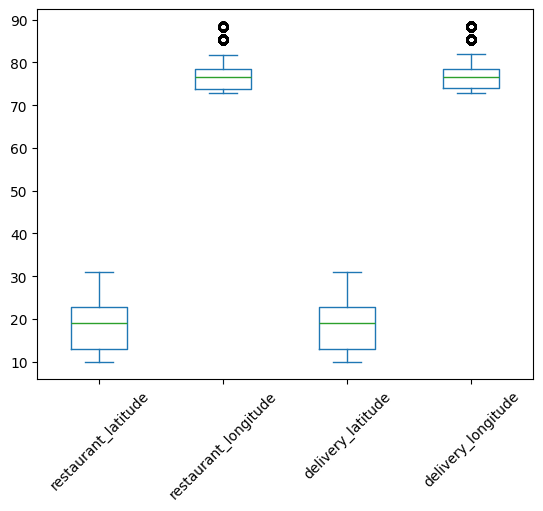

In [447]:
# location columns

cleaned_data[location_columns].plot(kind="box")

plt.xticks(rotation=45)

display(cleaned_data[location_columns].describe())

In [448]:
# values in categorical columns

cat_cols = cleaned_data.select_dtypes(include="object").columns.tolist()

for col in cat_cols:
    print(f"For {col} unique values are: {cleaned_data[col].unique()}",end="\n\n")

For rider_id unique values are: ['INDORES13DEL02 ' 'BANGRES18DEL02 ' 'BANGRES19DEL01 ' ...
 'KOCRES04DEL01 ' 'BHPRES06DEL03 ' 'GOARES03DEL03 ']

For weather unique values are: ['sunny' 'stormy' 'sandstorms' 'cloudy' 'fog' 'windy' nan]

For traffic unique values are: ['high' 'jam' 'low' 'medium' nan]

For type_of_order unique values are: ['snack' 'drinks' 'buffet' 'meal']

For type_of_vehicle unique values are: ['motorcycle' 'scooter' 'electric_scooter' 'bicycle']

For festival unique values are: ['no' 'yes' nan]

For city_type unique values are: ['urban' 'metropolitian' 'semi-urban' nan]

For city_name unique values are: ['INDO' 'BANG' 'COIMB' 'CHEN' 'HYD' 'RANCHI' 'MYS' 'DEH' 'KOC' 'PUNE'
 'LUDH' 'KNP' 'MUM' 'KOL' 'JAP' 'SUR' 'GOA' 'AURG' 'AGR' 'VAD' 'ALH' 'BHP']

For order_day_of_week unique values are: ['saturday' 'friday' 'tuesday' 'monday' 'sunday' 'wednesday' 'thursday']



<Axes: >

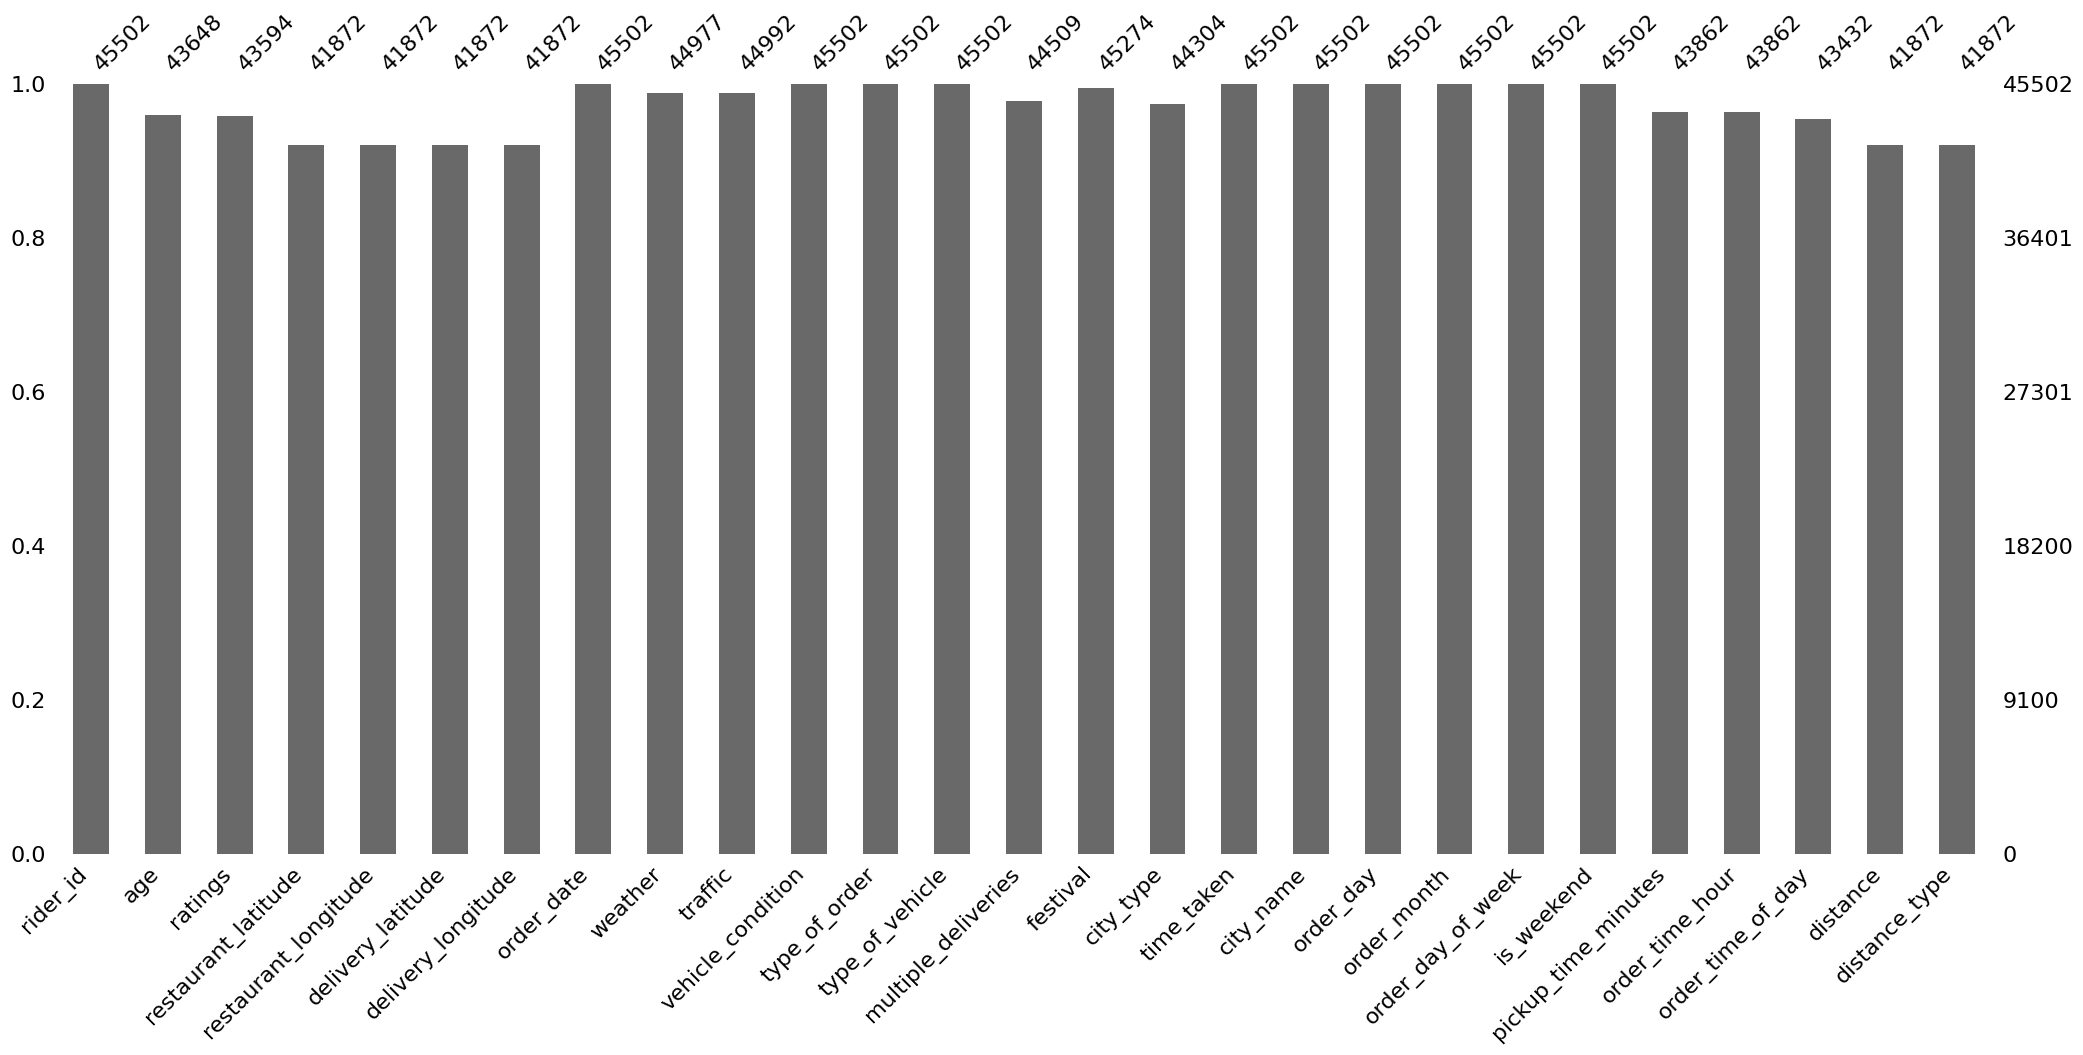

In [449]:
# bar plot of missing values

msno.bar(cleaned_data)

<Axes: >

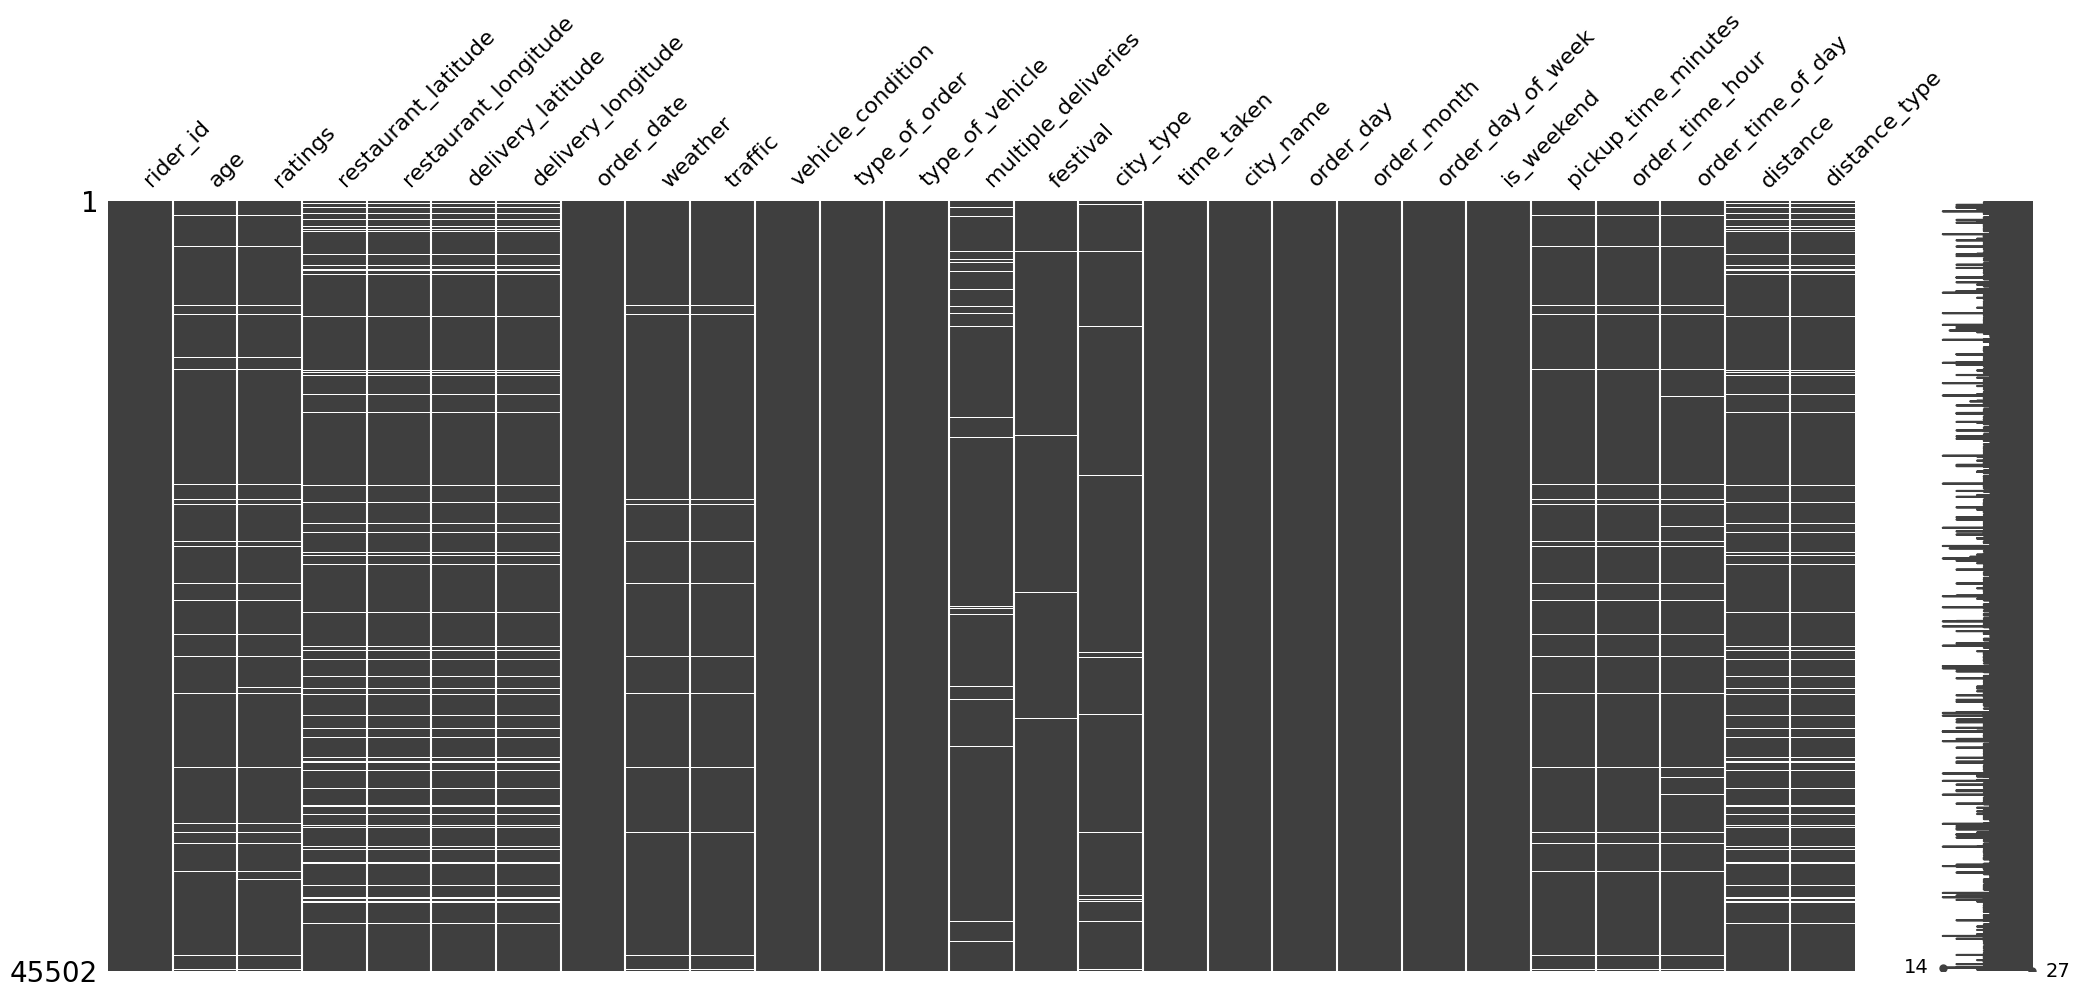

In [450]:
# matrix of missing values
msno.matrix(cleaned_data)

<Axes: >

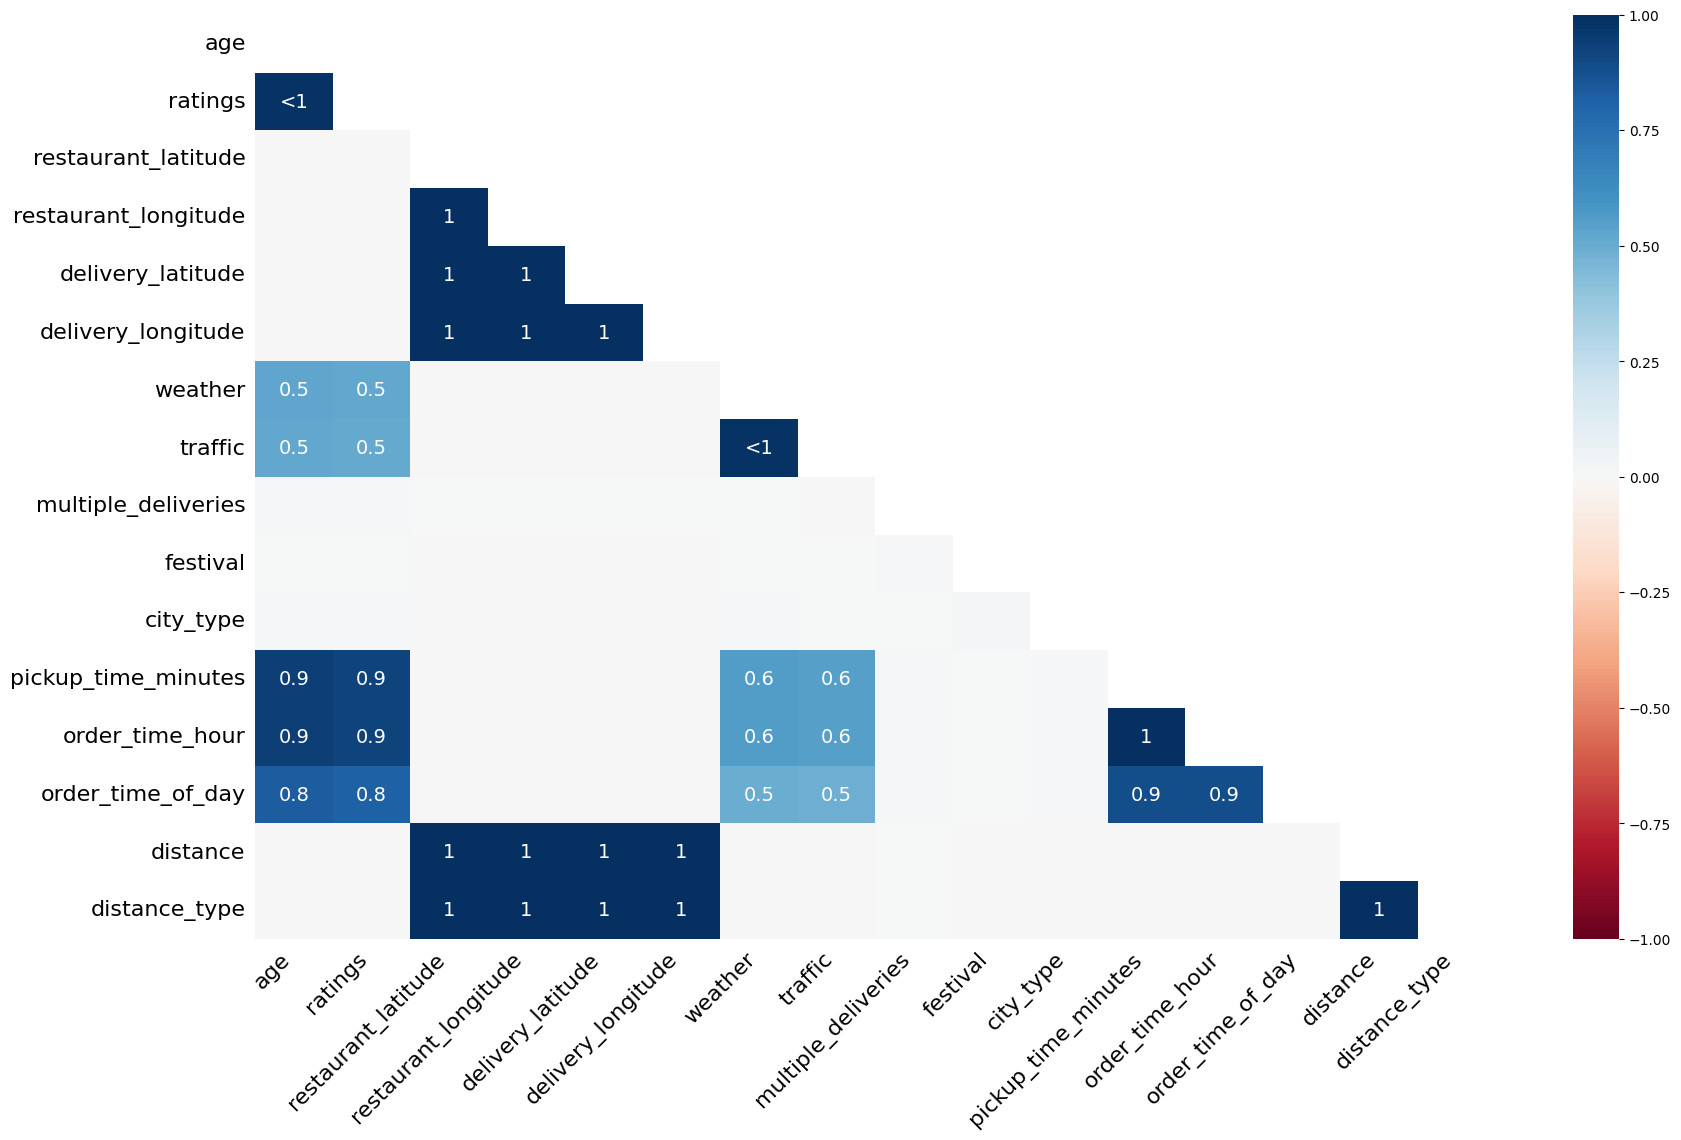

In [451]:
# correlation chart of missing values
msno.heatmap(cleaned_data)

# Save Cleaned Data

In [453]:
# save the cleaned data

cleaned_data.to_csv(parent / "data" / "cleaned_swiggy.csv",index=False)

In [454]:
cleaned_data.columns

Index(['rider_id', 'age', 'ratings', 'restaurant_latitude',
       'restaurant_longitude', 'delivery_latitude', 'delivery_longitude',
       'order_date', 'weather', 'traffic', 'vehicle_condition',
       'type_of_order', 'type_of_vehicle', 'multiple_deliveries', 'festival',
       'city_type', 'time_taken', 'city_name', 'order_day', 'order_month',
       'order_day_of_week', 'is_weekend', 'pickup_time_minutes',
       'order_time_hour', 'order_time_of_day', 'distance', 'distance_type'],
      dtype='object')